Unipolar NRZ Signaling: 

Generated Bits: [1 0 0 1 0 1 1 0 0 1]


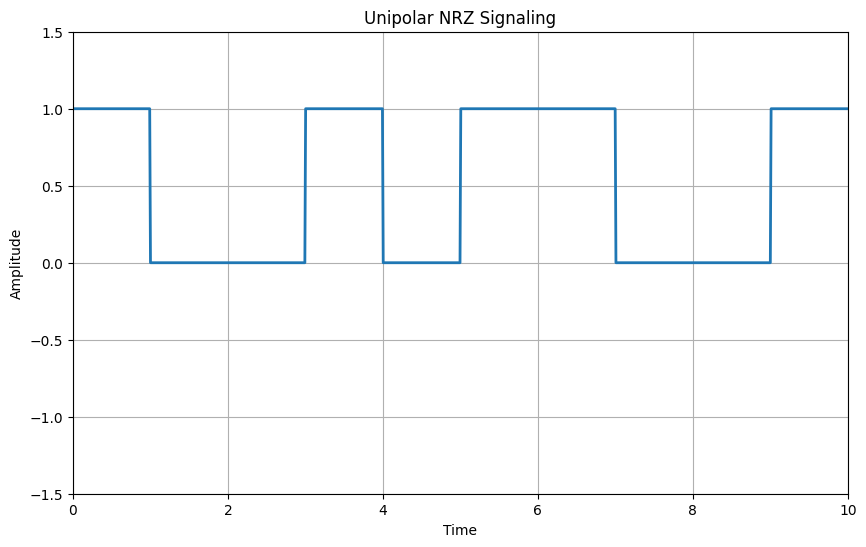

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup and Bit Generation
N = 10  # Number of bits
# np.random.randint(low, high, size) - high is exclusive, so 2 gives us 0s and 1s
n = np.random.randint(0, 2, N)
print(f"Generated Bits: {n}")

# 2. Mapping Function
# For Unipolar NRZ, the mapping is identity (0->0, 1->1).
# We copy n to nn to maintain the structure of your original code.
nn = n.astype(float) # Ensure it is float for plotting if needed

# 3. Signal Shaping
# In Python/Numpy, we avoid 'for' loops for performance.
# We use np.repeat to expand the bits into a waveform.
step = 0.01
samples_per_bit = int(1 / step) # 100 samples per bit

# Repeat each bit value 'samples_per_bit' times to create the square wave
y = np.repeat(nn, samples_per_bit)

# Create the time vector to match the length of y
t = np.linspace(0, N, len(y))

# 4. Plotting
plt.figure(figsize=(10, 6)) # Set figure size
plt.plot(t, y, linewidth=2)

# Axis setup: [x_min, x_max, y_min, y_max]
plt.axis([0, N, -1.5, 1.5])

plt.grid(True)
plt.title("Unipolar NRZ Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

### Polar NRZ Signaling: 

Input Bits: [0 1 0 1 0 1 0 1 1 1]
Mapped Levels: [-1  1 -1  1 -1  1 -1  1  1  1]


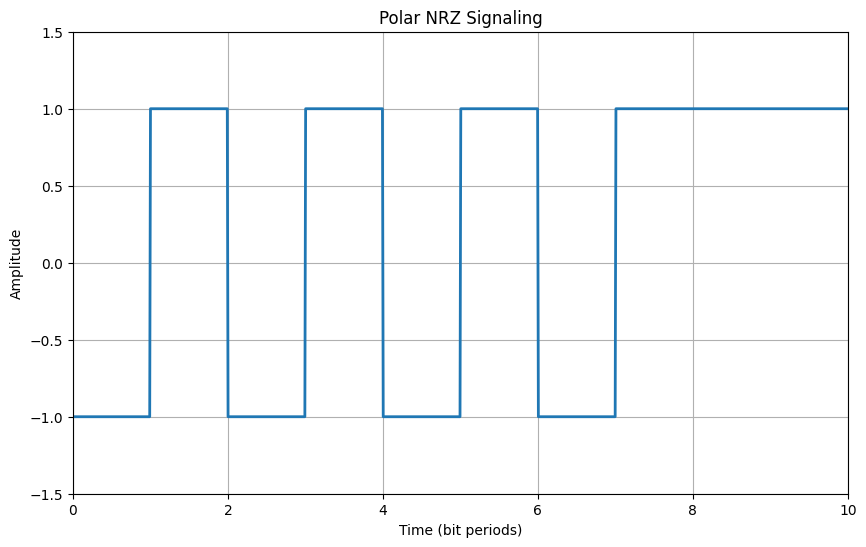

In [ ]:

# 1. Setup and Specific Bit Sequence
# Hardcoded bit sequence from your figure: 0 1 0 1 0 1 0 1 1 1
n = np.array([0, 1, 0, 1, 0, 1, 0, 1, 1, 1])
N = len(n)  # Number of bits (N=10)
print(f"Input Bits: {n}")

# 2. Mapping Function (Polar NRZ: 1 -> +1, 0 -> -1)
# np.where efficiently handles the mapping
nn = np.where(n == 1, 1, -1)
print(f"Mapped Levels: {nn}")

# 3. Signal Shaping
# We define the resolution to match the 0.01 step (100 samples per bit)
samples_per_bit = 100

# Use np.repeat to create the waveform by holding each level for 100 samples
y = np.repeat(nn, samples_per_bit)

# Create the time vector, ensuring it matches the length of y
t = np.linspace(0, N, len(y))

# 4. Plotting
plt.figure(figsize=(10, 6))
# Plot the signal
plt.plot(t, y, linewidth=2)

# Axis set-up: [x_min, x_max, y_min, y_max] to match the image
plt.axis([0, N, -1.5, 1.5])

plt.grid(True)
plt.title("Polar NRZ Signaling")
plt.xlabel("Time (bit periods)")
plt.ylabel("Amplitude")
plt.show()

### Unipolar RZ Signaling

Input Bits: [1 1 0 1 1 0 0 1 1 1]


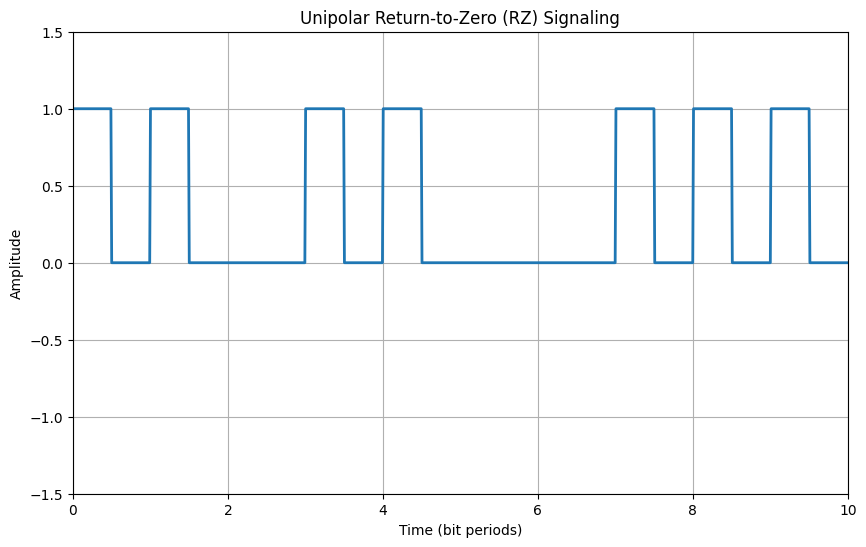

In [ ]:

# 1. Setup and Specific Bit Sequence
# Specific bit sequence from your output example
n = np.array([1, 1, 0, 1, 1, 0, 0, 1, 1, 1])
N = len(n)  # Number of bits (N=10)
print(f"Input Bits: {n}")

# 2. Signal Parameters (Matching the 0.01 resolution)
samples_per_bit = 100       # Total samples per bit period
half_samples = 50           # Samples for the pulse (0 to 0.5)

# 3. RZ Pulse Shaping (Vectorized Approach)
# Create an NRZ signal first
y_nrz = np.repeat(n, samples_per_bit)

# Create the RZ Mask: [1 (50 times), 0 (50 times)] repeated N times
# This mask ensures the second half of every bit period is zero.
rz_pulse_template = [1] * half_samples + [0] * half_samples
rz_mask = np.tile(rz_pulse_template, N)

# Apply the mask to convert NRZ to RZ
y_rz = y_nrz * rz_mask

# Create time vector (t=0 to N)
t = np.linspace(0, N, len(y_rz))

# 4. Plotting
plt.figure(figsize=(10, 6))
plt.plot(t, y_rz, linewidth=2)

# Axis set-up: [x_min, x_max, y_min, y_max]
plt.axis([0, N, -1.5, 1.5])
plt.grid(True)
plt.title("Unipolar Return-to-Zero (RZ) Signaling")
plt.xlabel("Time (bit periods)")
plt.ylabel("Amplitude")
plt.show()

### Bipolar RZ Signaling:

Input Binary Data (n): [0 0 1 1 0 0 0 1 1 1]
AMI Mapped Levels (nn): [ 0.  0.  1. -1.  0.  0.  0.  1. -1.  1.]


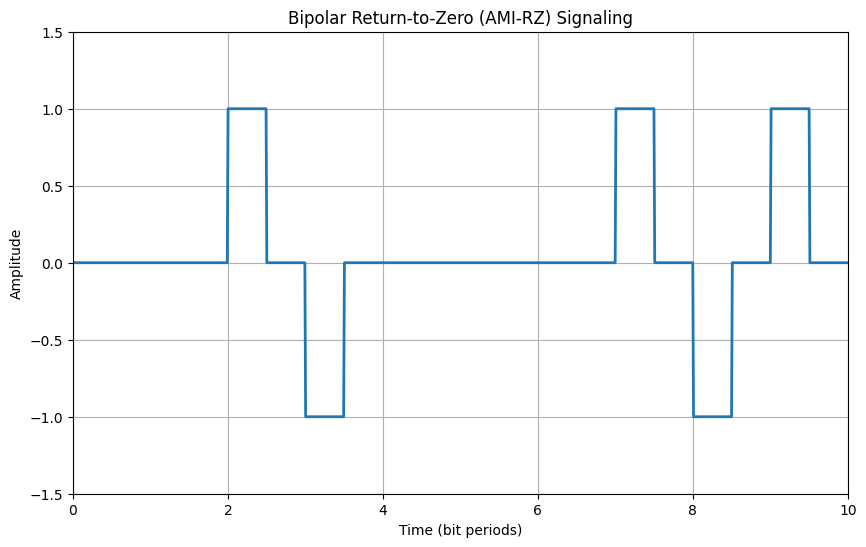

In [7]:

# 1. Setup and Specific Bit Sequence
# Specific bit sequence from your output example
n = np.array([0, 0, 1, 1, 0, 0, 0, 1, 1, 1])
N = len(n)
print(f"Input Binary Data (n): {n}")

# 2. Binary to Bipolar Conversion (AMI Rule)
# This requires a sequential loop because the output depends on previous state.
nn = np.zeros(N)
f = 1  # Alternating flag: 1 means next '1' is +1; -1 means next '1' is -1

for m in range(N):
    if n[m] == 1:
        if f == 1:
            nn[m] = 1.0  # Assign +1
            f = -1       # Next '1' will be -1
        else:
            nn[m] = -1.0 # Assign -1
            f = 1        # Next '1' will be +1
    else:
        nn[m] = 0.0      # Binary '0' maps to 0V

print(f"AMI Mapped Levels (nn): {nn}")

# 3. RZ Pulse Shaping (Vectorized Approach)
# This replaces the complex time-loop in the MATLAB code.
samples_per_bit = 100       # Total samples per bit period (from 0.01 step)
half_samples = 50           # Samples for the pulse (0 to 0.5)

# Create an AMI-NRZ equivalent signal first
y_ami_nrz = np.repeat(nn, samples_per_bit)

# Create the RZ Mask: [1 (50 times), 0 (50 times)] repeated N times
# This forces the signal to return to 0 in the second half of every bit.
rz_pulse_template = [1] * half_samples + [0] * half_samples
rz_mask = np.tile(rz_pulse_template, N)

# Apply the mask to convert AMI-NRZ to AMI-RZ
y_brz = y_ami_nrz * rz_mask

# Create time vector (t=0 to N)
t = np.linspace(0, N, len(y_brz))

# 4. Plotting
plt.figure(figsize=(10, 6))
plt.plot(t, y_brz, linewidth=2)

# Axis set-up: [x_min, x_max, y_min, y_max]
plt.axis([0, N, -1.5, 1.5])
plt.grid(True)
plt.title("Bipolar Return-to-Zero (AMI-RZ) Signaling")
plt.xlabel("Time (bit periods)")
plt.ylabel("Amplitude")
plt.show()

### Split-Phase 

Input Binary Data (n): [0 0 1 0 0 0 0 0 0 1]


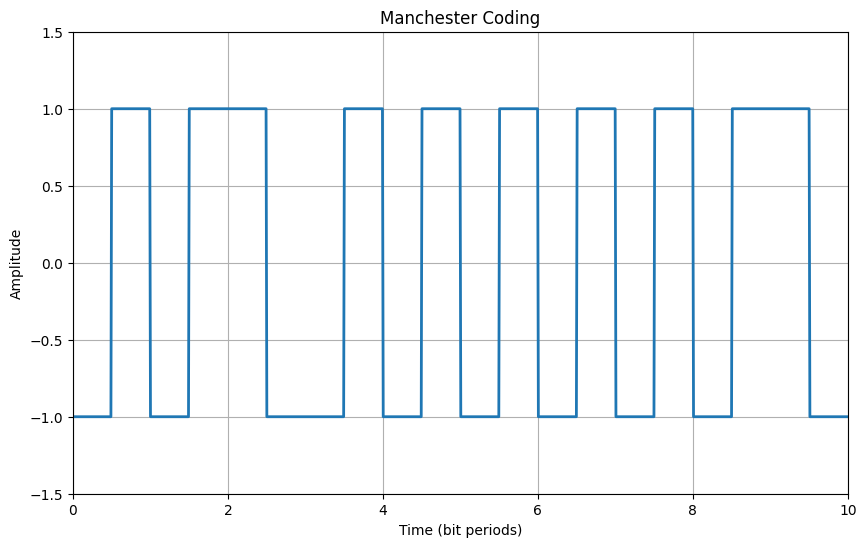

In [8]:

# 1. Setup and Specific Bit Sequence
# Specific bit sequence from your output example
n = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 1])
N = len(n)
print(f"Input Binary Data (n): {n}")

# 2. Binary to Manchester Conversion (Vectorized Mapping)
# Rule: 1 -> [+1, -1] (High-to-Low transition) | 0 -> [-1, +1] (Low-to-High transition)

# First Half of the Bit Period (1 maps to +1, 0 maps to -1)
nnn_half1 = np.where(n == 1, 1.0, -1.0)
# Second Half of the Bit Period (1 maps to -1, 0 maps to +1)
nnn_half2 = np.where(n == 1, -1.0, 1.0)

# Interleave the two half arrays to create the 2N sequence 'nnn'
# This array holds the signal level for every half-bit period.
nnn = np.stack((nnn_half1, nnn_half2), axis=1).flatten()

# 3. Pulse Shaping (Vectorized Signal Generation)
# Since the time step is 0.01, a full bit (duration 1) has 100 samples.
# Each element in 'nnn' represents a half-bit, so it needs 50 samples.
samples_per_half_bit = 50

# Repeat each half-bit level 50 times to create the square wave signal
y = np.repeat(nnn, samples_per_half_bit)

# Create time vector (t=0 to N)
t = np.linspace(0, N, len(y))

# 4. Plotting
plt.figure(figsize=(10, 6))
plt.plot(t, y, linewidth=2)

# Axis set-up: [x_min, x_max, y_min, y_max]
plt.axis([0, N, -1.5, 1.5])
plt.grid(True)
plt.title('Manchester Coding')
plt.xlabel("Time (bit periods)")
plt.ylabel("Amplitude")
plt.show()